# Image filtering

In this notebook, we'll explore the basics of image filtering using practical examples. Image filtering consists of modifying the intensity of the pixels in an image with a specific aim, such as:
* removing noise or background
* sharpening an image
* highlighting certain features

This process can aid certain tasks, such as thresholding. However, we should keep in mind that the pixel values in the image are being modified, and therefore, signal intensity should **not** be quantified on filtered images.

## Import libraries

In [1]:
import numpy as np
from scipy import ndimage
import skimage
import matplotlib.pyplot as plt
import stackview

## Morphological filters

Morphological filters are normally applied to binary masks to perform tasks such as removing small objects, filling holes, and closing edges. The idea is to turn pixels ON and OFF depending on their surroundings, changing whether they belong to the foreground or background class. 

The simplest to understand are the erosion and dilation filters. As their names indicate, these filters either shrink or enlarge ON objects. The size and shape of the filters specify what region is considered around objects to shrink or enlarge them. 

<img src="illustrations/morphological_operations.png" alt="drawing" width="90%" class="center"/>

<sub>Illustration taken from "Introduction to Bioimage Analysis" by Pete Bankhead, [CC-BY 4.0](https://creativecommons.org/licenses/by/4.0/).</sub>

Let's see this in action! We're going to start by creating a binary mask by thresholding an image

In [23]:
# load an example image
image = skimage.io.imread('images/cells_atlas/50546_727_A8_2.tif')

# subset the array to select the DAPI channel and zoom into a small rectangular region
image_nuclei = image[:700, :, 2]

# threshold with mean algorithm and create binary mask
threshold_otsu = skimage.filters.threshold_mean(image_nuclei)
binary_mask = image_nuclei > threshold_otsu

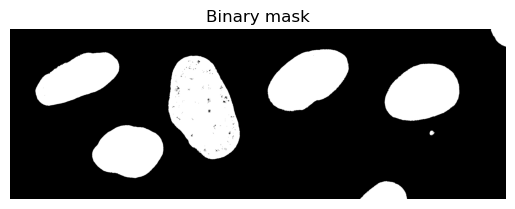

In [25]:
plt.imshow(binary_mask, cmap='gray')
plt.title('Binary mask')
plt.axis('off')
plt.show()

We can specify the shape and size of an erosion filter. For example, we can use a circle of radius 2:

In [26]:
binary_eroded = skimage.morphology.isotropic_erosion(binary_mask, radius=2)

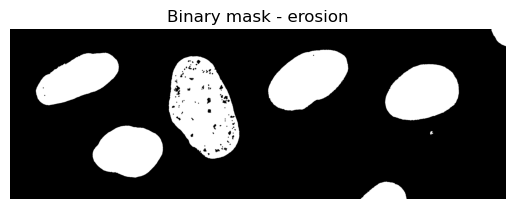

In [27]:
plt.imshow(binary_eroded, cmap='gray')
plt.title('Binary mask - erosion')
plt.axis('off')
plt.show()

We can specify the shape and size of a dilation filter as well. For example, for a circle of radius 2:

In [28]:
binary_dilated = skimage.morphology.isotropic_dilation(binary_mask, radius=2)

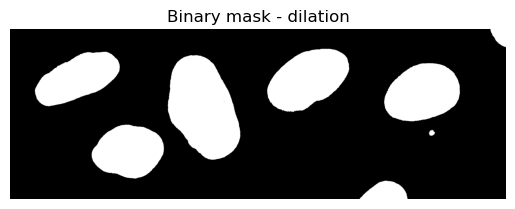

In [29]:
plt.imshow(binary_dilated, cmap='gray')
plt.title('Binary mask - dilation')
plt.axis('off')
plt.show()

We can run erosion and dilation processes in sequence to achieve the removal of small objects ([**morphological opening**](https://en.wikipedia.org/wiki/Opening_%28morphology%29): first erode, then dilate) or hole filling ([**morphological closing**](https://en.wikipedia.org/wiki/Closing_(morphology)): first dilate, then erode)

In [34]:
binary_open = skimage.morphology.isotropic_opening(binary_mask, radius=8)

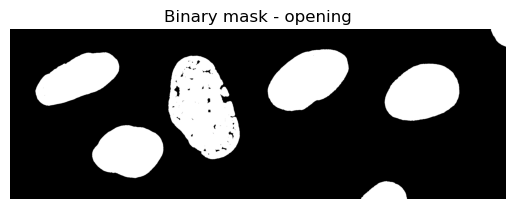

In [35]:
plt.imshow(binary_open, cmap='gray')
plt.title('Binary mask - opening')
plt.axis('off')
plt.show()

In [32]:
binary_close = skimage.morphology.isotropic_closing(binary_mask, radius=5)

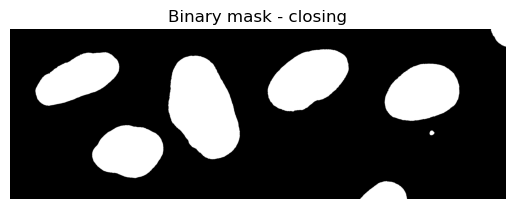

In [33]:
plt.imshow(binary_close, cmap='gray')
plt.title('Binary mask - closing')
plt.axis('off')
plt.show()

There's also another useful function in the `scipy` library, which can fill the holes in a binary image. We can see it in action below:

In [37]:
from scipy import ndimage

binary_fill = ndimage.binary_fill_holes(binary_mask)

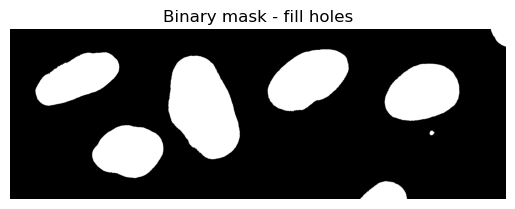

In [38]:
plt.imshow(binary_fill, cmap='gray')
plt.title('Binary mask - fill holes')
plt.axis('off')
plt.show()

## Image filters
Filtering images is at the core of denoising and image processing. The idea is to use a small image that travels across a larger image and does some operation on each sub-region. 

In the simplest case, we can imagine that a small square travels across the image and computes the *local mean* of the pixels with which it overlaps. This is then a *mean* filter.

Multiple properties of the *little travelling square* can change:
- The operation to be run on each sub-region, i.e., the pixel values of the kernel. This can be a local mean, median, Gaussian, etc.
- The size and shape of the "square"

Filters can be applied to regular images, as well as to masks (binary images) and are often used to denoise or segment images.

`scikit-image` has many filters available under `skimage.filters`.

<img src="illustrations/convolution.png" alt="drawing" width="50%" class="center"/>

## Image filtering

Example application: pre-processing before thresholding.

In [2]:
image = skimage.io.imread('https://cildata.crbs.ucsd.edu/media/images/13901/13901.tif')

In [3]:
stackview.curtain(image, image > 600, zoom_factor=0.5)

In [4]:
from skimage import filters
def preprocess(im):
    f = im
    f = f.astype(float) - filters.rank.minimum(f, footprint=np.ones((200,200), dtype='bool'))
    f = f * (f > 0)
    f = f / filters.gaussian(f, sigma=50)
    f = np.clip(f, 0, 4)
    return f

image_preprocessed = preprocess(image)

/opt/miniconda3/envs/env_day2/lib/python3.10/site-packages/skimage/filters/rank/generic.py:332: UserWarning: Bad rank filter performance is expected due to a large number of bins (4096), equivalent to an approximate bitdepth of 12.0.
  image, footprint, out, mask, n_bins = _preprocess_input(


In [5]:
print('Original vs preprocessed')
stackview.curtain(image, image_preprocessed, zoom_factor=0.5)

Original vs preprocessed


In [6]:
print('Original vs preprocessed and tresholded')

stackview.curtain(image, image_preprocessed>1.2, zoom_factor=0.5)

Original vs preprocessed and tresholded


## Image filtering

Example application: **Denoising** (removing noise from an image)

Noise is random variation of brightness or color information in images, which usually originates in the sensor / camera.

Consider the following image:

<img src="illustrations/noisy_nuclei.png" alt="drawing" width="50%" class="center"/>

## Image filters

The idea is to use a small image (or kernel) that travels across a larger image and does some operation on each sub-region of this larger image. For example, we can imagine that a small square of a given size travels across the image and computes the *local mean* of the pixels with which it overlaps. This is then a *mean filter*.

Multiple properties of the *little travelling square* can change:
- the pixel values of the square can be anything. For example it's common to have a 2D gaussian for smoothing the image (see below)
- the size and shape of the square can change
- the operation done by the square does not have to be a simple multiplication-addition (convolution). It can also be another function like a median for example.

Filters can be applied to regular images, as well as to masks (binary images) and are often used to denoise or segment images (see segmentation notebook).

What python package do we use for filtering? scikit-image has many filters available under ```skimage.filters```.

Multiple properties of the *little travelling square* can change:
- the pixel values of the square can be anything. For example it's common to have a 2D gaussian for smoothing the image (see below)
- the size and shape of the square can change
- the operation done by the square does not have to be a simple multiplication-addition (convolution). It can also be another function like a median for example.

Filters can be applied to regular images, as well as to masks (binary images) and are often used to denoise or segment images (see segmentation notebook).

What python package do we use for filtering? scikit-image has many filters available under ```skimage.filters```.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import skimage
import skimage.io
import skimage.morphology

## Linear (or convolutional) filters

<img src="illustrations/convolution.png" alt="drawing" width="50%" class="center"/>

### Python example

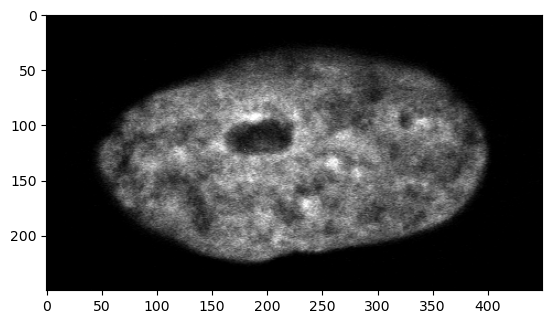

In [9]:
image = skimage.io.imread('images/cells_atlas/46658_784_B12_1.tif')[200:450, 250:700, 2]

plt.imshow(image, cmap='gray')

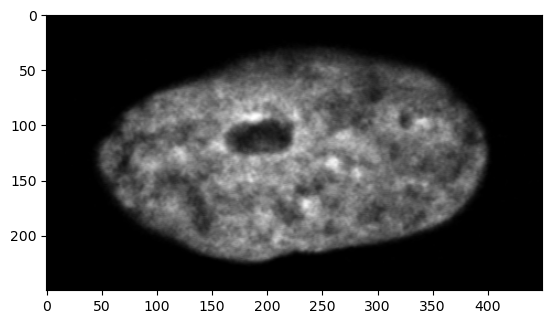

In [10]:
kernel = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
])
kernel = kernel / np.sum(kernel) # normalize the kernel

image_conv = ndimage.convolve(image, kernel)#, mode='constant', cval=0.0)

plt.imshow(image_conv, cmap='gray')

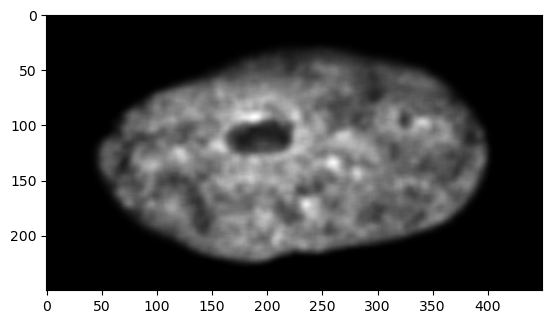

In [11]:
# kernel 7x7
kernel = np.array([
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1]
])

kernel = kernel / np.sum(kernel) # normalize the kernel

image_conv = ndimage.convolve(image, kernel)#, mode='constant', cval=0.0)

plt.imshow(image_conv, cmap='gray')

### The gaussian filter

<img src="illustrations/gaussian_kernel.png" alt="drawing" width="50%" class="center"/>

<sub>Adapted from (Shipitko et al, 2018)</sub>

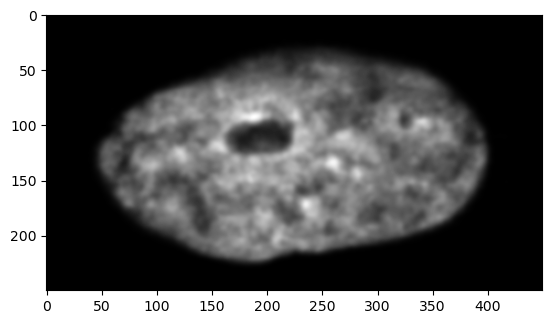

In [12]:
image_g = skimage.filters.gaussian(image, sigma=2, preserve_range=True)

plt.imshow(image_g, cmap='gray')

### Can we visualize the used kernel?

### Edge detection

Convolutional filters can also be used to detect edges in images. For this, a convolutional kernel is used that highlights the difference in intensity between neighboring pixels. In other words, the kernel is designed to have a high value when the intensity changes rapidly between two pixels.

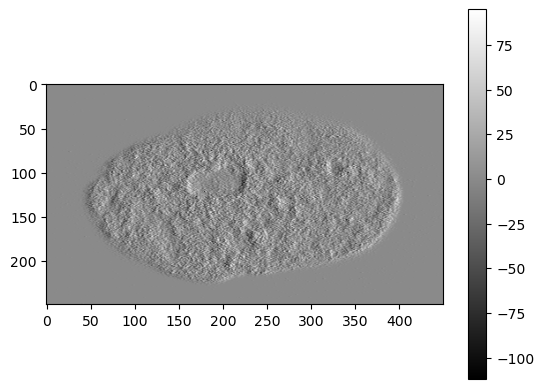

In [13]:
image = skimage.io.imread('images/cells_atlas/46658_784_B12_1.tif')[200:450, 250:700, 2].astype(float)

kernel = np.array([
    [-1, 0, 1],
])

image_conv = ndimage.convolve(
    # skimage.filters.gaussian(image, sigma=5, preserve_range=True),
    image,
    kernel)

# plt.imshow(np.abs(image_conv), cmap='gray')
plt.imshow(image_conv, cmap='gray')
plt.colorbar()

### Edge detection

Adding up the edges in the x and y directions gives a good approximation of the magnitude of the image intensity gradient of the image.

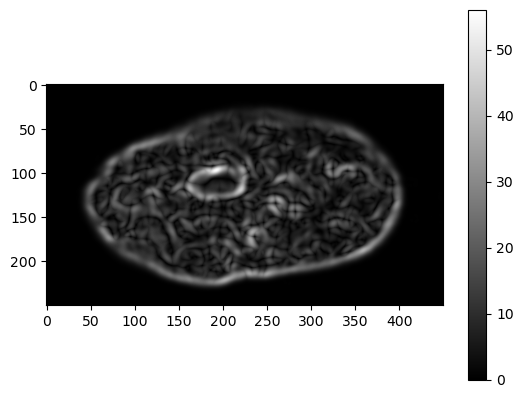

In [14]:
kernel1 = np.array([
    [-1, 0, 1],
])

kernel2 = np.array([
    [1],
    [0],
    [-1],
])

image_g = skimage.filters.gaussian(image, sigma=3, preserve_range=True)
image_conv = np.abs(ndimage.convolve(image_g, kernel1)) + np.abs(ndimage.convolve(image_g, kernel2))

plt.imshow(image_conv, cmap='gray')
plt.colorbar()

## Convolutional filters are used in deep learning

Similarly to detecting edges in images, convolutional filters are used in deep learning to detect all types of patterns in images.

In this process, the convolutional filter is learned from the data, rather than being pre-defined.

[![IMAGE ALT TEXT](http://img.youtube.com/vi/VUkFo6IXMJc/0.jpg)](http://www.youtube.com/watch?v=VUkFo6IXMJc "Video Title")

### Removing noise

Gaussian filtering does not only blur information, it also helps removing noise. Let's for example take again our blurred image and add some noise to it. For that we use the numpy random module:

In [15]:
noisy = skimage.util.random_noise(
    skimage.exposure.rescale_intensity(image, in_range=(0, 255), out_range=(0, 1)),
    mode='poisson')
noisy = noisy * 255
noisy = noisy.astype(np.uint8)

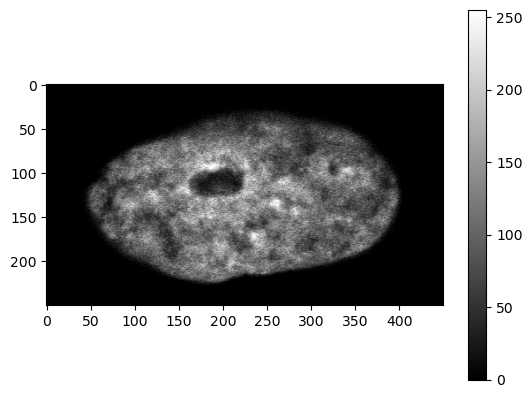

In [16]:
plt.imshow(noisy, cmap = 'gray');
plt.colorbar()

If we now apply again our gaussian filter:

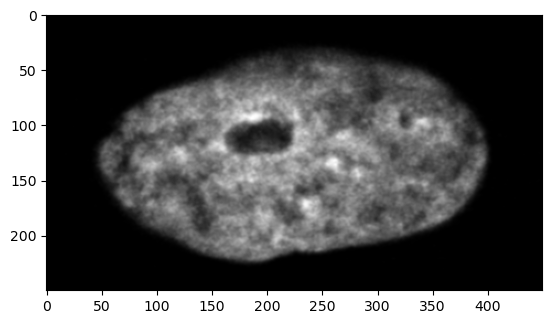

In [17]:
noisy_gaussian_filtered = skimage.filters.gaussian(noisy, sigma=1, preserve_range=True)
plt.imshow(noisy_gaussian_filtered, cmap = 'gray');

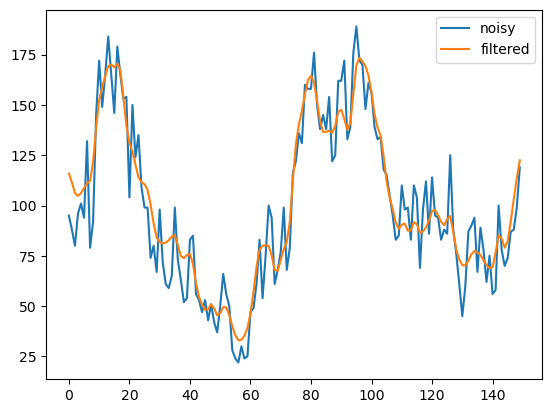

In [18]:
plt.plot(noisy[100, 150: 300], label='noisy')
plt.plot(noisy_gaussian_filtered[100, 150: 300], label='filtered')
plt.legend()

We obtain an image which of course is blurred, but where the strong noise appears strongly reduced.

## Non-linear filters

Another class of filters does not use convolution to filter the image but does some other type of operation on small neighborhoods of the image. For example it can calculate the median value of each 3x3 sub-region in the image. This is extremely useful if our image has pixels that are "dead" or have extremely large values.

For purpose of illustration, we can artificially create such an image using a skimage utility:

### The median filter

<img src="illustrations/median_filter.png" alt="drawing" width="40%" class="center"/>

<sub>Illustration adapted from https://www.southampton.ac.uk/~msn/book/new_demo/median/</sub>

We can choose a "footprint" (the size of the neighborhood) and apply the median filter to the image.

In [19]:
skimage.morphology.square(3)

array([[1, 1, 1],
       [1, 1, 1],
       [1, 1, 1]], dtype=uint8)

In [20]:
noisy_median_filtered = skimage.filters.rank.median(noisy, footprint=skimage.morphology.square(3))

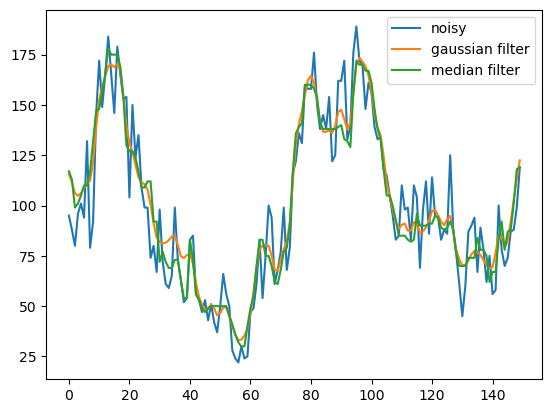

In [21]:
plt.plot(noisy[100, 150: 300], label='noisy')
plt.plot(noisy_gaussian_filtered[100, 150: 300], label='gaussian filter')
plt.plot(noisy_median_filtered[100, 150: 300], label='median filter')
plt.legend()

### Visualizing the difference between the noisy and the filtered image

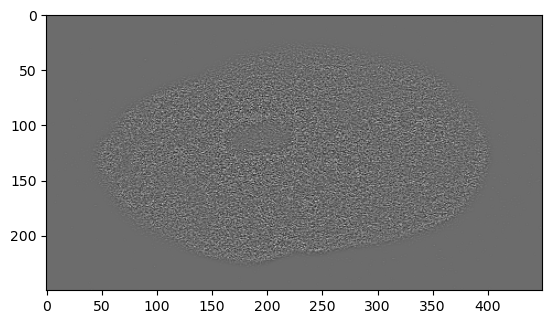

In [22]:
plt.imshow(noisy.astype(float) - noisy_gaussian_filtered, cmap = 'gray');

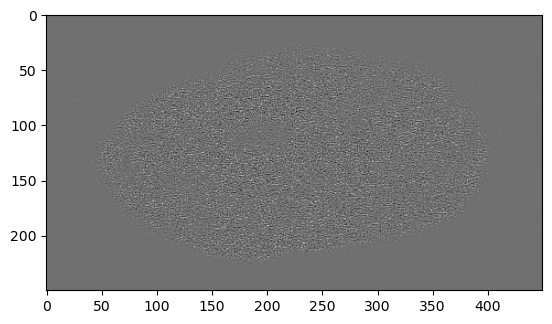

In [23]:
plt.imshow(noisy.astype(float) - noisy_median_filtered, cmap = 'gray');

## Morphological filters

<img src="illustrations/morphological_operations.png" alt="drawing" width="90%" class="center"/>

<sub>Illustration taken from "Introduction to Bioimage Analysis" by Pete Bankhead, [CC-BY 4.0](https://creativecommons.org/licenses/by/4.0/).</sub>

When working with masks, one can use another class of filters, that just turn pixels ON and OFF depending on their surroundings. The simplest to understand are the erosion and dilation filters. As their name indicate, these filters either shrink or enlarge ON objects. The size and shape of the filters, specify what region is considered around objects to shrink or enlarge them. We use here again the ```footprint``` argument to specify such structuring elements.

Let's create a simple mask by thresholding an image:

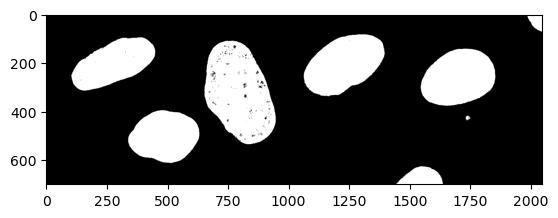

In [24]:
image = skimage.io.imread('images/cells_atlas/50546_727_A8_2.tif')
image_nuclei = image[:700, :, 2] # select DAPI and crop the image

mask = image_nuclei > 30

plt.imshow(mask, cmap='gray')

We can just specify the influence region as a Numpy array. For example a square of size 5:

In [25]:
eroded = skimage.morphology.isotropic_erosion(mask, radius=2)

In [42]:
stackview.curtain(mask, eroded, zoom_factor=0.5)

### Difference between the original and the eroded mask

In [41]:
stackview.curtain(mask, np.logical_xor(mask, eroded), zoom_factor=0.5)

In [43]:
dilated = skimage.morphology.isotropic_dilation(mask, radius=2)
stackview.curtain(mask, dilated, zoom_factor=0.5)

### How is this useful?

### Removing small objects using **morphological opening**

In [45]:
mask_processed = mask

radius = 5
mask_processed = skimage.morphology.isotropic_erosion(mask_processed, radius=radius)
mask_processed = skimage.morphology.isotropic_dilation(mask_processed, radius=radius)

# or: skimage.morphology.isotropic_closing

stackview.curtain(mask, mask_processed, zoom_factor=0.5)

### Filling holes and closing edges using **morphological closing**

In [46]:
mask_processed = mask

radius = 5
mask_processed = skimage.morphology.isotropic_dilation(mask_processed, radius=radius)
mask_processed = skimage.morphology.isotropic_erosion(mask_processed, radius=radius)

# or: skimage.morphology.isotropic_opening

stackview.curtain(mask, mask_processed, zoom_factor=0.5)

### Closing after opening

In [51]:
mask_processed = mask

radius = 5
mask_processed = skimage.morphology.isotropic_opening(mask_processed, radius=radius)
mask_processed = skimage.morphology.isotropic_closing(mask_processed, radius=radius)

stackview.curtain(mask, mask_processed, zoom_factor=0.5)

### Filling holes

In [52]:
from scipy import ndimage

mask_filled = ndimage.binary_fill_holes(mask_processed)

stackview.curtain(mask_processed, mask_filled, zoom_factor=0.5)